In [1]:
import pickle
import numpy as np
import deepchem as dc
from sklearn.feature_selection import VarianceThreshold
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading some PyTorch models, missing a dependency. No module named 'torch'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch'
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'torch'
Skipped loading some Jax models, missing a dependency. No module named 'jax'


In [2]:
def featurizer(featname, data, plant):
    if featname == "MACCS":
        featurizer_maccs = dc.feat.MACCSKeysFingerprint()
        data_features = featurizer_maccs.featurize(data['smiles'])
        plant_features = featurizer_maccs.featurize(plant['SMILES'])

        vt = VarianceThreshold(threshold=(.98 * (1 - .98)))
        data_selected = vt.fit_transform(data_features)
        mask = vt.get_support(indices=True)
        plant_selected = plant_features[:, mask]
        dataset = dc.data.NumpyDataset(data_selected, data['class'])
    
    elif featname == "RDkit":
        featurizer_rdkit = dc.feat.RDKitDescriptors()
        data_features = featurizer_rdkit.featurize(data['smiles'])
        plant_features = featurizer_rdkit.featurize(plant['SMILES'])

        vt = VarianceThreshold(threshold=(.98 * (1 - .98)))
        data_selected = vt.fit_transform(data_features)
        mask = vt.get_support(indices=True)
        plant_selected = plant_features[:, mask]
        dataset = dc.data.NumpyDataset(data_selected, data['class'])
    
    else:
        raise ValueError("Unsupported feature type")

    return dataset, plant_selected

In [4]:
data = pd.read_csv('../data/GABAA.csv',encoding='gb18030')
new_data = pd.read_excel('../data/application_domain.xlsx',sheet_name='Remove rdkit error SMILES')

new_maccs, plant_maccs = featurizer('MACCS', data, new_data)
new_rdkit, plant_rdkit = featurizer('RDkit', data, new_data)

In [5]:
nan_mask = np.isnan(plant_rdkit).any(axis=1)

In [6]:
nan_row_indices = np.where(nan_mask)[0]

In [7]:
nan_row_indices

array([], dtype=int64)

In [8]:
nan_row_indices

array([], dtype=int64)

In [9]:
# Load the first-level models from saved pickle files.
with open('rf_maccs_model.pkl', 'rb') as f:
    rf_maccs_model = pickle.load(f)

with open('rf_rdkit_model.pkl', 'rb') as f:
    rf_rdkit_model = pickle.load(f)

with open('svm_maccs_model.pkl', 'rb') as f:
    svm_maccs_model = pickle.load(f)

with open('xgb_maccs_model.pkl', 'rb') as f:
    xgb_maccs_model = pickle.load(f)

# Predict probabilities using the first-level models.
rf_maccs_pred = rf_maccs_model.predict_proba(plant_maccs)
rf_rdkit_pred = rf_rdkit_model.predict_proba(plant_rdkit)
svm_maccs_pred = svm_maccs_model.predict_proba(plant_maccs)
xgb_maccs_pred = xgb_maccs_model.predict_proba(plant_maccs)


D:\Miniconda\envs\sleep_model\lib\site-packages\sklearn\base.py:329: UserWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.2.2 when using version 1.0.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
  warnings.warn(
D:\Miniconda\envs\sleep_model\lib\site-packages\sklearn\base.py:329: UserWarning: Trying to unpickle estimator RandomForestClassifier from version 1.2.2 when using version 1.0.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
  warnings.warn(


[20:15:46] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:553: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by calling `Booster.save_model` from that version
  first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/latest/tutorials/saving_model.html

  for more details about differences between saving model and serializing.



In [10]:
# Merge the output of the first-level models (feature concatenation).
# This step combines the prediction probabilities from multiple models into a single feature matrix.
stacking_input = np.concatenate(
    (rf_maccs_pred, rf_rdkit_pred, svm_maccs_pred, xgb_maccs_pred),
    axis=1
)

In [11]:
# Load the second-level stacking model from a saved pickle file.
with open('stacking_model.pkl', 'rb') as f:
    stacking_model = pickle.load(f)

# Make predictions using the second-level stacking model.
stacking_pred = stacking_model.predict(stacking_input)
stacking_proba = stacking_model.predict_proba(stacking_input)

In [12]:
test_pred_list = []
for test_score in stacking_proba:
    test_score = test_score[1]
    test_pred_list.append(test_score)

In [13]:
test_pred_array = np.array(test_pred_list)

In [14]:
df = pd.DataFrame({
    'Scientific_name':new_data['Scientific_name'],
    'Chinese_name':new_data['Chinese_name'],
    'Extraction_site':new_data['Extraction_site'],
    'Volatile_compounds':new_data['Volatile_compounds'],
    'Compound_content':new_data['Compound_content'],
    'Analysis_method':new_data['Analysis_method'],
    'Cite':new_data['Cite'],
    'SMILES':new_data['SMILES'],
    'pred':test_pred_array
})

In [15]:
df

,Scientific_name,Chinese_name,Extraction_site,Volatile_compounds,Compound_content,Analysis_method,Cite,SMILES,pred
0,Lamium album,短柄野芝麻,flower,"6,10,14-Trimethylpentadecan-2-one",0.102,GC-MS,"Morteza-Semnani K, Saeedi M, Akbarzadeh M. Che...",CC(C)CCCC(C)CCCC(C)CCCC(=O)C,1.0000
1,Lamium album,短柄野芝麻,flower,Diacetone alcohol,0.091,GC-MS,"Morteza-Semnani K, Saeedi M, Akbarzadeh M. Che...",CC(=O)CC(C)(C)O,1.0000
2,Lamium album,短柄野芝麻,flower,1-Pentanol,0.041,GC-MS,"Morteza-Semnani K, Saeedi M, Akbarzadeh M. Che...",CCCCCO,1.0000
3,Lamium album,短柄野芝麻,flower,Tetracosane,0.039,GC-MS,"Morteza-Semnani K, Saeedi M, Akbarzadeh M. Che...",CCCCCCCCCCCCCCCCCCCCCCCC,1.0000
4,Lamium album,短柄野芝麻,flower,Tricosane,0.037,GC-MS,"Morteza-Semnani K, Saeedi M, Akbarzadeh M. Che...",CCCCCCCCCCCCCCCCCCCCCCC,1.0000
...,...,...,...,...,...,...,...,...,...
15443,Hyssopus officinalis,神香草,leaf,Myrtenyl acetate,0.0098,GC-MS,"KIZIL S, HAŞİMİ N, Tolan V, et al. Chemical co...",CC(=O)OCC1=CCC2CC1C2(C)C,1.0000
15444,Hyssopus officinalis,神香草,leaf,cis-Pinonic acid,0.0063,GC-MS,"KIZIL S, HAŞİMİ N, Tolan V, et al. Chemical co...",CC(=O)C1CC(C1(C)C)CC(=O)O,1.0000
15445,Hyssopus officinalis,神香草,leaf,beta-bisabolene,0.0057,GC-MS,"KIZIL S, HAŞİMİ N, Tolan V, et al. Chemical co...",CC1=CCC(CC1)C(=C)CCC=C(C)C,1.0000
15446,Hyssopus officinalis,神香草,leaf,Elemol,0.0055,GC-MS,"KIZIL S, HAŞİMİ N, Tolan V, et al. Chemical co...",CC(=C)C1CC(CCC1(C)C=C)C(C)(C)O,1.0000


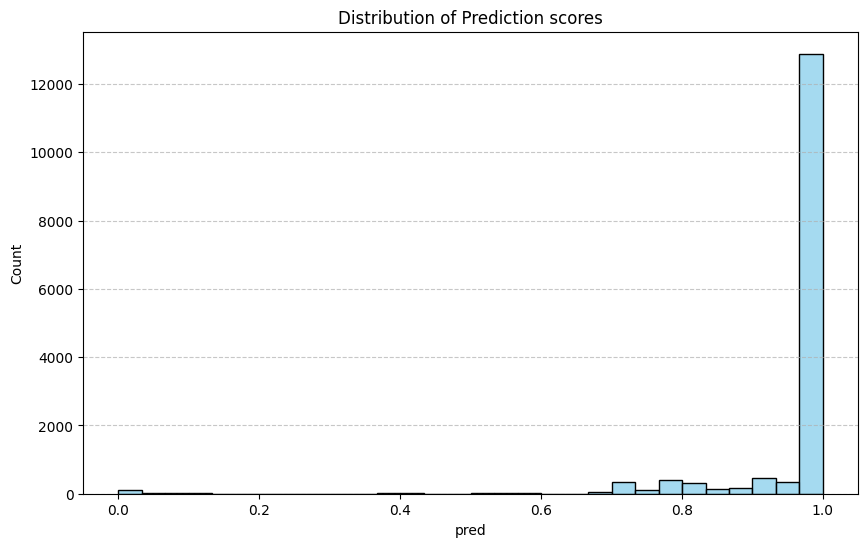

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(df['pred'], bins=30, kde=False, color='skyblue', edgecolor='black')
plt.title('Distribution of Prediction scores')
plt.xlabel('pred')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [16]:
count_above_0_5 = df[df['pred'] >= 0.5].shape[0]
count_above_0_9 = df[df['pred'] >= 0.9].shape[0]
count_above_0_95 = df[df['pred'] >= 0.95].shape[0]

# Output the results
print(f"Number of probabilities above 0.5: {count_above_0_5}")
print(f"Number of probabilities above 0.9: {count_above_0_9}")
print(f"Number of probabilities above 0.95: {count_above_0_95}")

Number of probabilities above 0.5: 15268
Number of probabilities above 0.9: 13710
Number of probabilities above 0.95: 13185


Delete duplicate value

In [17]:
def featurizer(featname, data, plant):
    if featname == "MACCS":
        featurizer_maccs = dc.feat.MACCSKeysFingerprint()
        data_features = featurizer_maccs.featurize(data['smiles'])
        plant_features = featurizer_maccs.featurize(plant['SMILES'])

        vt = VarianceThreshold(threshold=(.98 * (1 - .98)))
        data_selected = vt.fit_transform(data_features)
        mask = vt.get_support(indices=True)
        plant_selected = plant_features[:, mask]
        dataset = dc.data.NumpyDataset(data_selected, data['class'])
    
    elif featname == "RDkit":
        featurizer_rdkit = dc.feat.RDKitDescriptors()
        data_features = featurizer_rdkit.featurize(data['smiles'])
        plant_features = featurizer_rdkit.featurize(plant['SMILES'])

        vt = VarianceThreshold(threshold=(.98 * (1 - .98)))
        data_selected = vt.fit_transform(data_features)
        mask = vt.get_support(indices=True)
        plant_selected = plant_features[:, mask]
        dataset = dc.data.NumpyDataset(data_selected, data['class'])
    
    else:
        raise ValueError("Unsupported feature type")

    return dataset, plant_selected

In [18]:
data = pd.read_csv('../data/GABAA.csv',encoding='gb18030')
new_data = pd.read_excel('../data/application_domain.xlsx',sheet_name='Remove duplicate samples')

new_maccs, plant_maccs = featurizer('MACCS', data, new_data)
new_rdkit, plant_rdkit = featurizer('RDkit', data, new_data)

In [19]:
nan_mask = np.isnan(plant_rdkit).any(axis=1)

In [20]:
nan_row_indices = np.where(nan_mask)[0]

In [21]:
nan_row_indices

array([], dtype=int64)

In [22]:
nan_row_indices

array([], dtype=int64)

In [23]:
# Load the first-level models from saved pickle files.
with open('rf_maccs_model.pkl', 'rb') as f:
    rf_maccs_model = pickle.load(f)

with open('rf_rdkit_model.pkl', 'rb') as f:
    rf_rdkit_model = pickle.load(f)

with open('svm_maccs_model.pkl', 'rb') as f:
    svm_maccs_model = pickle.load(f)

with open('xgb_maccs_model.pkl', 'rb') as f:
    xgb_maccs_model = pickle.load(f)

# Predict probabilities using the first-level models.
rf_maccs_pred = rf_maccs_model.predict_proba(plant_maccs)
rf_rdkit_pred = rf_rdkit_model.predict_proba(plant_rdkit)
svm_maccs_pred = svm_maccs_model.predict_proba(plant_maccs)
xgb_maccs_pred = xgb_maccs_model.predict_proba(plant_maccs)


[20:17:16] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:553: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by calling `Booster.save_model` from that version
  first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/latest/tutorials/saving_model.html

  for more details about differences between saving model and serializing.



D:\Miniconda\envs\sleep_model\lib\site-packages\sklearn\base.py:329: UserWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.2.2 when using version 1.0.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
  warnings.warn(
D:\Miniconda\envs\sleep_model\lib\site-packages\sklearn\base.py:329: UserWarning: Trying to unpickle estimator RandomForestClassifier from version 1.2.2 when using version 1.0.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [24]:
# Merge the output of the first-level models (feature concatenation).
# This step combines the prediction probabilities from multiple models into a single feature matrix.
stacking_input = np.concatenate(
    (rf_maccs_pred, rf_rdkit_pred, svm_maccs_pred, xgb_maccs_pred),
    axis=1
)

In [25]:
# Load the second-level stacking model from a saved pickle file.
with open('stacking_model.pkl', 'rb') as f:
    stacking_model = pickle.load(f)


# Make predictions using the second-level stacking model.
stacking_pred = stacking_model.predict(stacking_input)
stacking_proba = stacking_model.predict_proba(stacking_input)

In [26]:
test_pred_list = []
for test_score in stacking_proba:
    test_score = test_score[1]
    test_pred_list.append(test_score)

In [27]:
test_pred_array = np.array(test_pred_list)

In [28]:
df = pd.DataFrame({
    'Scientific_name':new_data['Scientific_name'],
    'Chinese_name':new_data['Chinese_name'],
    'Extraction_site':new_data['Extraction_site'],
    'Volatile_compounds':new_data['Volatile_compounds'],
    'Compound_content':new_data['Compound_content'],
    'Analysis_method':new_data['Analysis_method'],
    'Cite':new_data['Cite'],
    'SMILES':new_data['SMILES'],
    'pred':test_pred_array
})

In [29]:
df

,Scientific_name,Chinese_name,Extraction_site,Volatile_compounds,Compound_content,Analysis_method,Cite,SMILES,pred
0,Lamium album,短柄野芝麻,flower,"6,10,14-Trimethylpentadecan-2-one",0.102,GC-MS,"Morteza-Semnani K, Saeedi M, Akbarzadeh M. Che...",CC(C)CCCC(C)CCCC(C)CCCC(=O)C,1.000000
1,Lamium album,短柄野芝麻,flower,Diacetone alcohol,0.091,GC-MS,"Morteza-Semnani K, Saeedi M, Akbarzadeh M. Che...",CC(=O)CC(C)(C)O,1.000000
2,Lamium album,短柄野芝麻,flower,1-Pentanol,0.041,GC-MS,"Morteza-Semnani K, Saeedi M, Akbarzadeh M. Che...",CCCCCO,1.000000
3,Lamium album,短柄野芝麻,flower,Tetracosane,0.039,GC-MS,"Morteza-Semnani K, Saeedi M, Akbarzadeh M. Che...",CCCCCCCCCCCCCCCCCCCCCCCC,1.000000
4,Lamium album,短柄野芝麻,flower,Tricosane,0.037,GC-MS,"Morteza-Semnani K, Saeedi M, Akbarzadeh M. Che...",CCCCCCCCCCCCCCCCCCCCCCC,1.000000
...,...,...,...,...,...,...,...,...,...
2366,Glechoma hederacea,欧活血丹,overground part,"2-Butanone, 4-(2,6,6-trimethyl-2-cyclohexen-1-...",0.0121,GC-MS,"Chou S T, Lai C C, Lai C P, et al. Chemical co...",CC1=CCCC(C1=CCC(=O)C)(C)C,0.980000
2367,Glechoma hederacea,欧活血丹,overground part,Nopol,0.0283,GC-MS,"Chou S T, Lai C C, Lai C P, et al. Chemical co...",CC1(C2CC=C(C1C2)CCO)C,1.000000
2368,Glechoma hederacea,欧活血丹,overground part,"6,6-Dimethylbicyclo[3.1.1]heptan-2-one",0.0209,GC-MS,"Chou S T, Lai C C, Lai C P, et al. Chemical co...",CC1(C2CCC(=O)C1C2)C,0.806167
2369,Hyssopus officinalis,神香草,leaf,"3,5,5-Trimethylbicyclo[2.2.1]heptan-2-one",0.5727,GC-MS,"KIZIL S, HAŞİMİ N, Tolan V, et al. Chemical co...",CC1C2CC(C1=O)CC2(C)C,0.862500


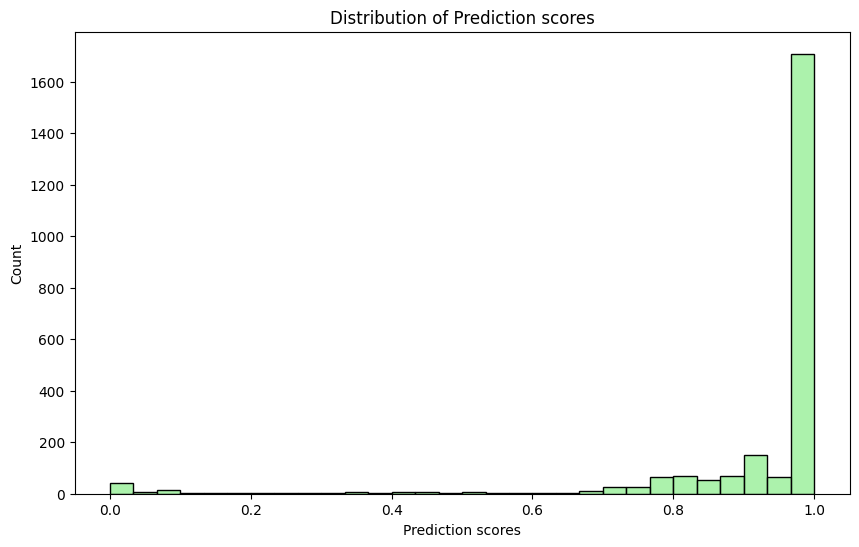

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(df['pred'], bins=30, kde=False, color='#90EE90', edgecolor='black')
plt.title('Distribution of Prediction scores')
plt.xlabel('Prediction scores')
plt.ylabel('Count')
#plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [31]:
count_above_0_5 = df[df['pred'] >= 0.5].shape[0]
count_above_0_9 = df[df['pred'] >= 0.9].shape[0]
count_above_0_95 = df[df['pred'] >= 0.95].shape[0]

# Output the results
print(f"Number of probabilities above 0.5: {count_above_0_5}")
print(f"Number of probabilities above 0.9: {count_above_0_9}")
print(f"Number of probabilities above 0.95: {count_above_0_95}")

Number of probabilities above 0.5: 2267
Number of probabilities above 0.9: 1927
Number of probabilities above 0.95: 1739
